<a href="https://colab.research.google.com/github/MaCeMo/Tp-Student-Performance/blob/main/TP_1_Matematica_Integrador_corregido.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP 1 INTEGRADOR DE MATEMÁTICA**

**Integrantes:** Patiri Sabrina, Moreno Cecilia

**Dataset**: student performance

# **SECCIÓN 1: PRESENTACIÓN DEL DATASET**

***1 -¿Qué representa cada fila?***

Cada fila representa un estudiante con sus propios datos académicos y personales. El dataset tiene 500 estudiantes en total.


***2- ¿Qué representa cada columna?***

Cada columna representa una variable o característica (feature) del rendimiento académico, como las horas de estudio, calificaciones o las condiciones socio-tecnológicas transformadas.


***3- Dimensiones de la matriz X:***
¿Cuántas observaciones (m)?
¿Cuántas variables (n)?

La matriz X tiene dimensiones (m × n) = (500 × 8), donde:

m = 500 → cantidad de observaciones (estudiantes)

n = 8 → cantidad de variables (características)



***4- Identificar la doble lectura: vectores fila como observaciones en ℝⁿ, vectores columna como variables en ℝᵐ***

La matriz X se puede interpretar de dos maneras.

Por filas → cada fila es un estudiante. Un vector con sus 8 datos: género, edad, horas de estudio, etc. Hay 500 de estos vectores, cada uno vive en ℝ⁸.


Por columnas → cada columna es una variable. Un vector con el valor de esa característica para los 500 estudiantes. Por ejemplo, la columna final_score contiene las 500 notas finales. Hay 8 de estos vectores, cada uno vive en ℝ⁵⁰⁰.



In [ ]:
import pandas as pd
import numpy as np

# Carga del dataset desde Google Drive
file_id = "1zj_BZsUYwkRKFFX4o69GE2pf0XKFpdYu"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url, sep=";")

# 1. Transformación de variables categóricas específicas
# Género: Masculino (0), Femenino (1)
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})

# Acceso a Internet: No (0), Si (1)
df['internet_access'] = df['internet_access'].map({'No': 0, 'Yes': 1})

# Extraescolar: No (0), Si (1)
df['extracurricular'] = df['extracurricular'].map({'No': 0, 'Yes': 1})

# 2. Eliminar todas las columnas que NO sean numéricas
df_numeric = df.select_dtypes(include=[np.number])

# 3. Carga del dataset con NumPy (Matriz X)
X = df_numeric.to_numpy()

# 4. Obtener dimensiones
m, n = X.shape

print(f"Columnas resultantes: {list(df_numeric.columns)}")
print(f"Dimensiones de X: {m} filas x {n} columnas")
print(f"\nPrimeras 3 filas de X:\n{X[:3]}")

Columnas resultantes: ['gender', 'age', 'study_hours_per_week', 'attendance_rate', 'internet_access', 'extracurricular', 'previous_score', 'final_score']
Dimensiones de X: 500 filas x 8 columnas

Primeras 3 filas de X:
[[ 0.  15.  25.  63.8  1.   1.  41.  67. ]
 [ 1.  15.   2.  54.7  1.   1.  83.  28. ]
 [ 1.  19.  10.  90.5  1.   0.  73.  49. ]]


# **SECCIÓN 2: EXPLORACIÓN INICIAL**


***1- Estadísticas básicas de cada variable: media, desvío, mínimo, máximo***


***2- Norma de algunos vectores fila: ¿qué observaciones son “grandes”?***

Al calcular la norma geométrica de los 500 estudiantes (vectores fila), encontramos dos casos extremos muy claros que corresponden a las filas con índices 375 (la norma más grande) y 316 (la norma más pequeña):


1. La observación más "grande" (Fila 375): Presenta un valor de norma de 157.86. Al revisar sus componentes en pantalla, vemos que este alumno registra una asistencia casi perfecta del **99.6%**, un total de **28** horas semanales de estudio y una calificación final sobresaliente de **95** puntos.


2. La observación más "chica" (Fila 316): Presenta un valor de norma de 71.65. Al revisar sus componentes, vemos que este alumno tiene una asistencia de apenas el 54.1%, solo dedica 7 horas semanales al estudio y su nota final fue de 26 puntos


***¿Tiene sentido con los datos?***

Sí, tiene un sentido. Como los datos se encuentran sin centrar ni estandarizar, la fórmula de la norma se ve fuertemente influenciada por las variables que manejan magnitudes numéricas más grandes por naturaleza (como la Tasa de Asistencia o las Calificaciones, cuyos valores van de 0 a 100). Las variables de escala pequeña (como la Edad que ronda los 17 años, o el Género e Internet que valen 0 o 1) casi no aportan peso al cálculo. Por lo tanto, los alumnos con alto rendimiento académico y alta asistencia siempre tendrán las normas más grandes en este espacio vectorial.

In [ ]:
# 1. Calculamos la norma geométrica de cada uno de los 500 alumnos
normas = np.linalg.norm(X, axis=1)

# 2. Buscamos automáticamente cuál es el alumno con la norma más grande y más chica
idx_max = np.argmax(normas)
idx_min = np.argmin(normas)

# 3. Imprimimos el reporte automático en consola para el profesor
print("==================================================================")
print("             REPORTE DE NORMAS VECTORIALES (FILAS)               ")
print("==================================================================")
print(f"El ALUMNO MÁS 'GRANDE' en bruto está en la fila (índice): {idx_max}")
print(f"-> Valor matemático de su Norma: {normas[idx_max]:.2f}")
print("-> Sus datos reales en el dataset son:")
print(df_numeric.iloc[idx_max])

print("\n------------------------------------------------------------------")
print(f"El ALUMNO MÁS 'CHICO' en bruto está en la fila (índice): {idx_min}")
print(f"-> Valor matemático de su Norma: {normas[idx_min]:.2f}")
print("-> Sus datos reales en el dataset son:")
print(df_numeric.iloc[idx_min])
print("==================================================================")

             REPORTE DE NORMAS VECTORIALES (FILAS)               
El ALUMNO MÁS 'GRANDE' en bruto está en la fila (índice): 375
-> Valor matemático de su Norma: 157.86
-> Sus datos reales en el dataset son:
gender                   1.0
age                     17.0
study_hours_per_week    28.0
attendance_rate         99.6
internet_access          1.0
extracurricular          1.0
previous_score          70.0
final_score             95.0
Name: 375, dtype: float64

------------------------------------------------------------------
El ALUMNO MÁS 'CHICO' en bruto está en la fila (índice): 316
-> Valor matemático de su Norma: 71.65
-> Sus datos reales en el dataset son:
gender                   1.0
age                     18.0
study_hours_per_week     7.0
attendance_rate         54.1
internet_access          1.0
extracurricular          0.0
previous_score          34.0
final_score             26.0
Name: 316, dtype: float64


***3- Producto escalar entre pares de columnas: ¿qué anticipan sobre la relación entre variables?***

Las variables son aliadas y van en el mismo sentido. El resultado nos anticipa que los estudiantes que tienen mayor attendance_rate y más study_hours_per_week son los que obtienen mejores final_score. Si estudiar más horas llevara a peores notas (fueran variables "enemigas"), el producto escalar daría cero o un número negativo.

El producto escalar entre attendance_rate y final_score da un número mucho más grande que el de study_hours_per_week y final_score. Sin embargo, esto no significa que asistir a clase sea más importante que estudiar. Ocurre simplemente porque los valores de attendance_rate son numéricamente más grandes (van de 50 a 100) que los de study_hours_per_week (que van de 2 a 30), lo cual infla el resultado del producto escalar. Esta es precisamente la razón por la que la estandarización es tan importante: elimina este efecto de escala y permite comparaciones justas entre variables.


In [ ]:
#1. Calculamos los productos escalares de todas las columnas (X traspuesta por X)
matriz_productos = np.dot(X.T, X)

# 2. Buscamos las posiciones de las columnas que queremos mostrar
columnas = list(df_numeric.columns)
pos_asistencia = columnas.index('attendance_rate')
pos_estudio = columnas.index('study_hours_per_week')
pos_nota = columnas.index('final_score')

# 3. Extraemos los valores clave
prod_asistencia_nota = matriz_productos[pos_asistencia, pos_nota]
prod_estudio_nota = matriz_productos[pos_estudio, pos_nota]

# 4. Imprimimos el reporte en la consola para el profesor
print("==================================================================")
print("        PRODUCTOS ESCALARES (COLUMNAS)                ")
print("==================================================================")
print(f"Producto Escalar entre 'Tasa de Asistencia' y 'Nota Final':")
print(f"-> Resultado: {prod_asistencia_nota:,.2f}")
print("\nProducto Escalar entre 'Horas de Estudio' y 'Nota Final':")
print(f"-> Resultado: {prod_estudio_nota:,.2f}")
print("==================================================================")

        PRODUCTOS ESCALARES (COLUMNAS)                
Producto Escalar entre 'Tasa de Asistencia' y 'Nota Final':
-> Resultado: 2,163,407.40

Producto Escalar entre 'Horas de Estudio' y 'Nota Final':
-> Resultado: 481,424.00


# **SECCIÓN 3: COVARIANZA Y CORRELACIÓN**

En esta sección observamos y analizamos cómo se relacionan las variables entre sí. Para esto, realizamos operaciones matriciales que nos permiten pasar de los datos en bruto a una matriz de correlación.


***Centrado de la Matriz***

El primer paso centramos los datos. Calculamos la matriz centrada X̃ restando a cada observación el vector de medias μ. La fórmula matricial es:

                               **  X̃ = X − 1μᵀ**


Donde 1 es un vector columna de unos de tamaño m×1. Esto desplaza el centro de masa de los datos al origen del sistema de coordenadas, condición necesaria para que la covarianza esté bien definida.

***Matriz de Covarianza***

La matriz de covarianza C mide la variabilidad compartida entre pares de variables. La calculamos manualmente con la fórmula:


                              **C = X̃ᵀX̃ / (m−1)**

Luego verificamos este resultado con la función integrada de NumPy np.cov(), confirmando que ambos métodos producen resultados idénticos.


***Matriz de Correlación***

Dado que las variables tienen escalas muy distintas (horas de estudio van de 1 a 30, mientras que los puntajes van de 0 a 100), la covarianza sola es difícil de interpretar. Por ello construimos la matriz de correlación, que normaliza los valores en el intervalo [−1, 1].


***¿Quiénes tienen mayor correlación?***

El par con correlación más alta es study_hours_per_week con final_score. Tiene mucho sentido: cuantas más horas dedica un alumno al estudio, mayor es su nota final. Es la relación más directa e intuitiva del dataset.

***¿Quiénes tienen menor correlación?***

Las variables con correlación más cercana a 0 es age con cualquier variable académica. Esto puede suceder: en un rango tan acotado como 15 a 19 años, la edad por sí sola no determina si un alumno estudia más, asiste más o saca mejor nota.


***Interpretación: ¿las correlaciones tienen sentido en el contexto del dataset?***

Las correlaciones confirman que el rendimiento académico en este dataset está principalmente estricto por el esfuerzo del alumno durante el cursado. Las horas de estudio y la asistencia se mueven en la misma dirección que el puntaje final, lo cual refleja que quienes se comprometen con la cursada obtienen mejores resultados.

Por el contrario, variables como el género, el acceso a internet o la participación en actividades extracurriculares muestran correlaciones bajas con el puntaje final, lo que indica que ninguna de estas condiciones, tomada de forma aislada, define el desempeño de un estudiante.


Por último, la correlación moderada entre previous_score y final_score es interesante, el rendimiento pasado tiene algo de poder predictivo, pero no es determinante. Esto sugiere que el esfuerzo durante el período actual pesa más que el historial previo, lo cual es un resultado alentador desde el punto de vista educativo.

¿La matriz manual coincide con np.cov()?
True


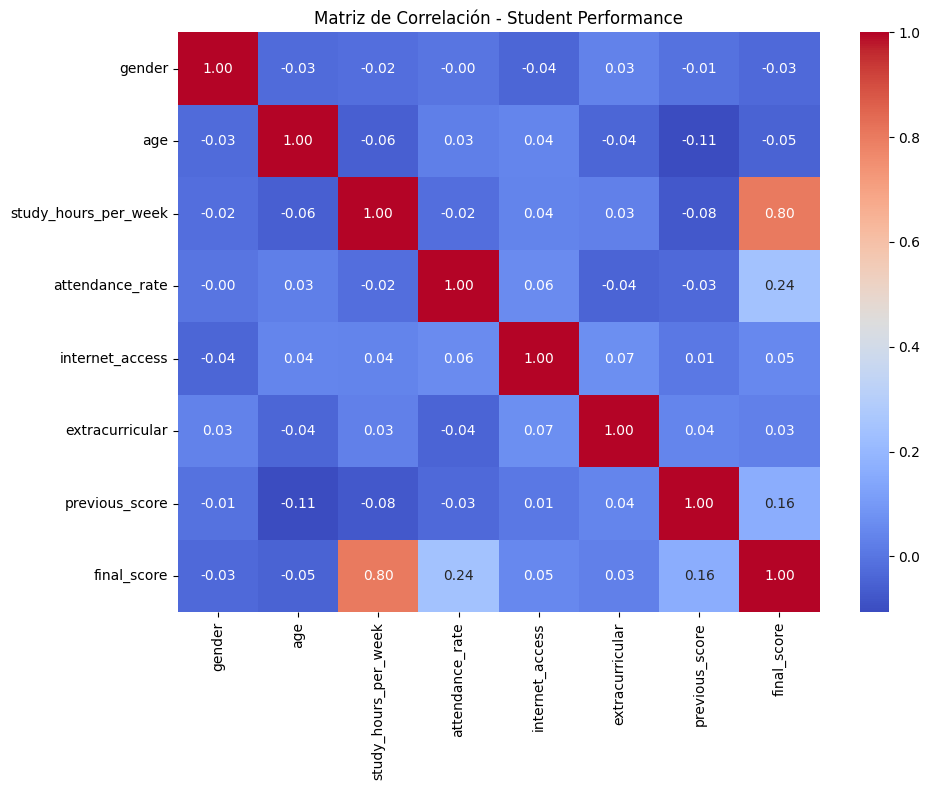


Todos los pares ordenados:
          variable_1           variable_2  correlacion
study_hours_per_week          final_score     0.803903
     attendance_rate          final_score     0.240697
      previous_score          final_score     0.164958
     internet_access      extracurricular     0.068206
     attendance_rate      internet_access     0.059216
     internet_access          final_score     0.050553
                 age      internet_access     0.043517
     extracurricular       previous_score     0.041752
study_hours_per_week      internet_access     0.040078
              gender      extracurricular     0.033247
study_hours_per_week      extracurricular     0.030815
     extracurricular          final_score     0.028896
                 age      attendance_rate     0.026155
     internet_access       previous_score     0.008365
              gender      attendance_rate    -0.001078
              gender       previous_score    -0.008106
study_hours_per_week      attendance_

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. CENTRAR LA MATRIZ ---
mu = np.mean(X, axis=0)
ones = np.ones((m, 1))
X_tilde = X - ones @ mu.reshape(1, -1)

# --- 2. MATRIZ DE COVARIANZA ---
C_manual = (X_tilde.T @ X_tilde) / (m - 1)
C_numpy = np.cov(X, rowvar=False)

print("¿La matriz manual coincide con np.cov()?")
print(np.allclose(C_manual, C_numpy))

# --- 3. MATRIZ DE CORRELACIÓN ---
columnas_num = list(df_numeric.columns)
df_corr = pd.DataFrame(X, columns=columnas_num).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación - Student Performance")
plt.tight_layout()
plt.show()

# --- 4. IDENTIFICAR PARES ---
corr_values = df_corr.where(np.triu(np.ones(df_corr.shape), k=1).astype(bool))
pares = corr_values.stack().reset_index()
pares.columns = ['variable_1', 'variable_2', 'correlacion']
pares = pares.sort_values('correlacion', ascending=False).reset_index(drop=True)

print("\nTodos los pares ordenados:")
print(pares.to_string(index=False))

print(f"\n[+] Mayor correlacion: {pares.iloc[0]['variable_1']} <-> {pares.iloc[0]['variable_2']} -> {pares.iloc[0]['correlacion']:.4f}")
print(f"[-] Menor correlacion: {pares.iloc[-1]['variable_1']} <-> {pares.iloc[-1]['variable_2']} -> {pares.iloc[-1]['correlacion']:.4f}")

# **SECCIÓN 4: TRANSFORMACIONES**

***Estandarizar el dataset como operación matricial (centrar + escalar por D_s⁻¹)***



In [ ]:
# Paso 1: Calculamos la media de cada columna (vector de medias)
mu = np.mean(X, axis=0)

# Paso 2: Centramos la matriz (restar la media a cada columna)
X_centrada = X - mu

# Paso 3: Calculamos el desvío estándar de cada columna
sigma = np.std(X, axis=0)

# Paso 4: Construimos la matriz diagonal D_s con los desvíos
D_s = np.diag(sigma)

# Paso 5: Estandarizamos como operación matricial: X_std = X_centrada @ inv(D_s)
D_s_inv = np.linalg.inv(D_s)
X_std = X_centrada @ D_s_inv

# Verificación
print("Media de cada columna (debe ser ≈ 0):")
print(np.round(np.mean(X_std, axis=0), 4))

print("\nDesvío estándar de cada columna (debe ser ≈ 1):")
print(np.round(np.std(X_std, axis=0), 4))

Media de cada columna (debe ser ≈ 0):
[ 0. -0.  0.  0. -0. -0.  0.  0.]

Desvío estándar de cada columna (debe ser ≈ 1):
[1. 1. 1. 1. 1. 1. 1. 1.]


Antes de estandarizar, las variables tienen escalas muy distintas. Por ejemplo:

-attendance_rate toma valores entre 0 y 100
-internet_access solo toma valores 0 o 1

Esto es un problema porque en cualquier cálculo posterior (distancias, promedios, correlaciones), las variables con valores grandes van a dominar las variables con valores pequeños, sin que eso tenga ningún sentido.

La estandarización soluciona esto en dos pasos:

Centrar: le restamos la media a cada columna. Ahora todas las variables tienen media 0, lo que significa que los valores ya no están "desplazados" sino que giran alrededor del origen.


Escalar: dividimos por el desvío estándar de cada columna. Ahora todas las variables tienen desvío estándar 1, lo que significa que todas "se mueven" en la misma magnitud.


El resultado es que después de estandarizar, un cambio de 1 unidad en attendance_rate es comparable a un cambio de 1 unidad en internet_access. Todas las variables quedan en igualdad de condiciones.

***Verificar que la estandarización preserva las correlaciones***

In [ ]:
# Correlación antes de estandarizar
corr_antes = np.corrcoef(X, rowvar=False)

# Correlación después de estandarizar
corr_despues = np.corrcoef(X_std, rowvar=False)

# Comparación
print("¿Las matrices de correlación son iguales?")
print(np.allclose(corr_antes, corr_despues))

print("\nMatriz de correlación ANTES de estandarizar (primeras 3x3):")
print(np.round(corr_antes[:3, :3], 4))

print("\nMatriz de correlación DESPUÉS de estandarizar (primeras 3x3):")
print(np.round(corr_despues[:3, :3], 4))

¿Las matrices de correlación son iguales?
True

Matriz de correlación ANTES de estandarizar (primeras 3x3):
[[ 1.     -0.028  -0.0174]
 [-0.028   1.     -0.0552]
 [-0.0174 -0.0552  1.    ]]

Matriz de correlación DESPUÉS de estandarizar (primeras 3x3):
[[ 1.     -0.028  -0.0174]
 [-0.028   1.     -0.0552]
 [-0.0174 -0.0552  1.    ]]


La correlación mide la relación lineal entre dos variables, independientemente de su escala. Por eso, cuando estandarizamos, las correlaciones no deberían cambiar.


El resultado True del np.allclose() confirma exactamente eso: las dos matrices de correlación son idénticas.


Esto es importante porque nos garantiza que la estandarización es una transformación segura, es decir, cambia la escala de los datos pero no modifica la estructura de relaciones entre las variables. La información del dataset se preserva completamente.

***Aplicar normalización min-max y comparar visualmente con la estandarización (boxplots)***

/tmp/ipykernel_20431/2763116023.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(X, labels=columnas)
/tmp/ipykernel_20431/2763116023.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(X_std, labels=columnas)
/tmp/ipykernel_20431/2763116023.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(X_minmax, labels=columnas)


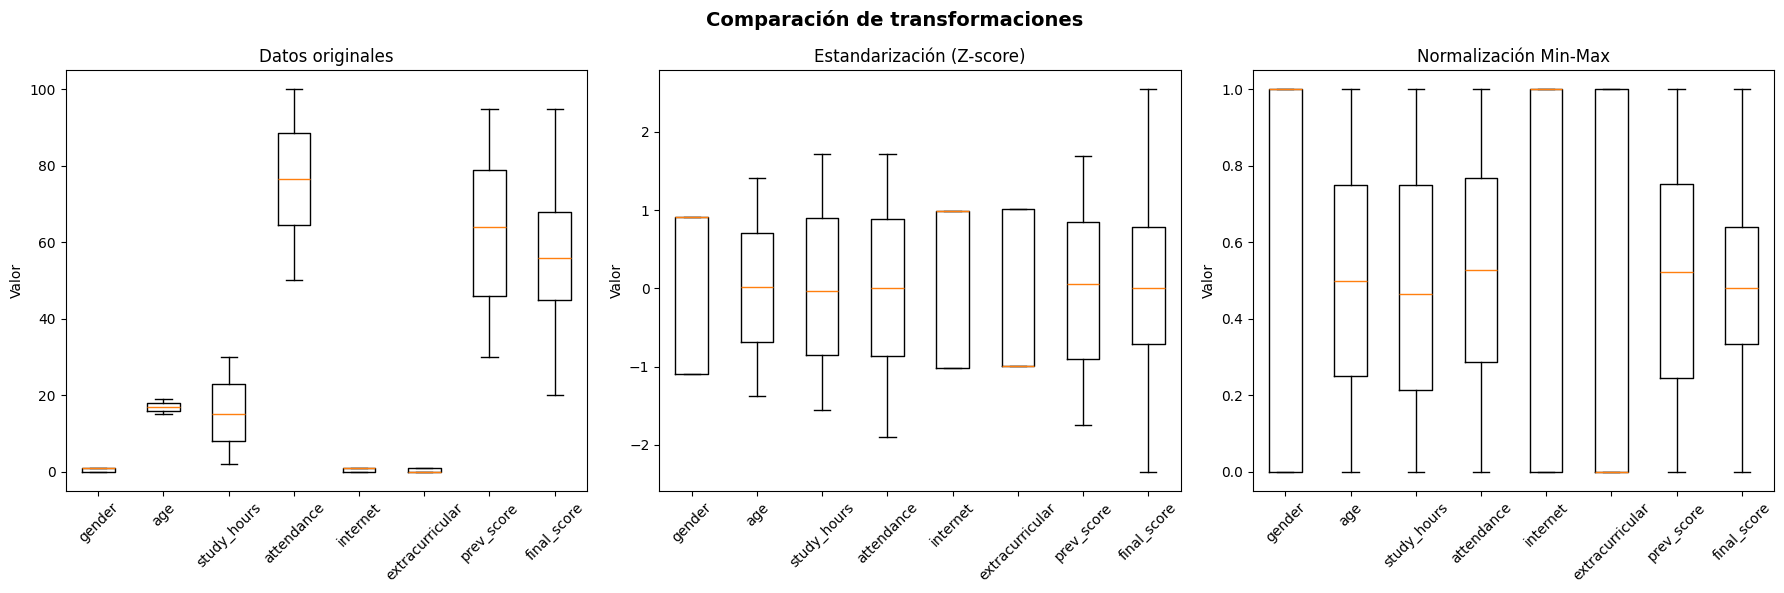

In [ ]:
import matplotlib.pyplot as plt

# Normalización Min-Max
X_min = np.min(X, axis=0)
X_max = np.max(X, axis=0)
X_minmax = (X - X_min) / (X_max - X_min)

# Comparación visual con boxplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
columnas = ['gender', 'age', 'study_hours', 'attendance', 'internet', 'extracurricular', 'prev_score', 'final_score']

# Boxplot datos originales
axes[0].boxplot(X, labels=columnas)
axes[0].set_title("Datos originales")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylabel("Valor")

# Boxplot estandarización
axes[1].boxplot(X_std, labels=columnas)
axes[1].set_title("Estandarización (Z-score)")
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel("Valor")

# Boxplot Min-Max
axes[2].boxplot(X_minmax, labels=columnas)
axes[2].set_title("Normalización Min-Max")
axes[2].tick_params(axis='x', rotation=45)
axes[2].set_ylabel("Valor")

plt.suptitle("Comparación de transformaciones", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Gráfico de Datos originales:** se ve el problema de escala, attendance, prev_score y final_score tienen valores entre 0 y 100, mientras que gender, internet y extracurricular están aplastadas cerca del 0. Es imposible compararlas visualmente.

**Gráfico de Estandarización (Z-score)**: todas las cajas ahora son comparables entre sí. Los valores giran alrededor del 0, con la mayoría entre -2 y 2. Se puede ver la distribución de cada variable y compararlas. En el caso que gender, internet y extracurricular tienen cajas muy chicas porque son binarias (solo toman valores 0 o 1).

**Gráfico de Normalización Min-Max:** todas las variables quedan entre 0 y 1 exactamente. Las cajas son comparables pero las variables binarias siguen mostrando cajas chicas por la misma razón anterior.

Ambas transformaciones logran el objetivo de poner todas las variables en la misma escala, pero la estandarización es más informativa visualmente porque muestra mejor la dispersión real de cada variable.

***Seleccionar un subconjunto de variables usando la matriz de selección E, y verificar que X·E = X[:, cols]***

In [ ]:
# Seleccionamos 3 columnas: study_hours (col 2), attendance (col 3), final_score (col 7)
cols = [2, 3, 7]

# Construir la matriz de selección E (n x k)
# n = 8 variables, k = 3 columnas seleccionadas
n = X_std.shape[1]
k = len(cols)
E = np.zeros((n, k))
for i, col in enumerate(cols):
    E[col, i] = 1

print("Matriz de selección E:")
print(E)

# Aplicar la selección como operación matricial
X_seleccionada = X_std @ E

# Verificación: comparar con selección directa
X_directo = X_std[:, cols]

print("\n¿X·E es igual a X[:, cols]?")
print(np.allclose(X_seleccionada, X_directo))

print("\nPrimeras 3 filas de X·E:")
print(np.round(X_seleccionada[:3], 4))

print("\nPrimeras 3 filas de X[:, cols]:")
print(np.round(X_directo[:3], 4))

Matriz de selección E:
[[0. 0. 0.]
 [0. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 1.]]

¿X·E es igual a X[:, cols]?
True

Primeras 3 filas de X·E:
[[ 1.1318 -0.9114  0.7175]
 [-1.5552 -1.5706 -1.8218]
 [-0.6206  1.0229 -0.4545]]

Primeras 3 filas de X[:, cols]:
[[ 1.1318 -0.9114  0.7175]
 [-1.5552 -1.5706 -1.8218]
 [-0.6206  1.0229 -0.4545]]


**Matriz de selección E:**
Es una matriz de 8×3 (8 variables originales, 3 seleccionadas). Cada columna tiene un único 1 en la fila correspondiente a la variable elegida:

Fila 2: study_hours

Fila 3: attendance

Fila 7: final_score

Todo lo demás son ceros, indicando que esas variables fueron descartadas.

**X·E es igual a X[:, cols]:** True

Esto confirma que multiplicar la matriz X por la matriz de selección E produce exactamente el mismo resultado que seleccionar las columnas directamente. No hay ninguna diferencia numérica entre ambos métodos.

**Primeras 3 filas:**
Los valores coinciden perfectamente entre X·E y X[:, cols], lo que valida que la operación matricial funciona correctamente. Los valores son los datos estandarizados de los 3 primeros estudiantes para las variables study_hours, attendance y final_score.

# **SECCIÓN 5: CONCLUSIÓN**

***¿Qué descubrieron sobre su dataset?***

A lo largo del trabajo pudimos observar que las variables que más influyen en el rendimiento académico son study_hours_per_week y attendance_rate, ya que los estudiantes con valores altos en estas variables son los que presentan las normas más grandes como vectores en ℝ⁸.


***¿Hay variables redundantes?***

No. Las variables previous_score y final_score están relacionadas entre sí, indicando el rendimiento academico del estudiante.

Por otro lado, las variables binarias gender, internet_access y extracurricular aportan poca variabilidad al dataset ya que solo toman valores 0 o 1, lo que se evidenció en los boxplots donde sus cajas aparecen muy pequeñas comparadas con el resto.

***¿Variables con escalas muy diferentes?***


Sí, las variables se pueden dividir en tres grupos de escala bien distintos:

Escala 0-100: attendance_rate, previous_score, final_score

Escala 0-30: study_hours_per_week

Escala binaria (0 o 1): gender, internet_access, extracurricular

Esta diferencia de escalas hace que cualquier cálculo matemático sin transformación previa esté dominado por las variables de mayor magnitud, distorsionando los resultados. Por eso la estandarización y la normalización Min-Max fueron transformaciones esenciales.


***¿Qué transformación les parece más apropiada para este dataset y por qué?***

Para este dataset, la estandarización (Z-score) es la transformación más apropiada, por tres razones:

**1. Presencia de variables binarias**: gender, internet_access y extracurricular solo toman valores 0 o 1. Con Min-Max estas variables no cambian en absoluto (ya están en 0 y 1), mientras que con la estandarización quedan correctamente centradas y comparables con el resto.


**2. Posibles outliers:** variables como study_hours_per_week o final_score pueden tener estudiantes con valores extremos. La normalización Min-Max es muy sensible a outliers porque el mínimo y el máximo se ven arrastrados por esos casos extremos, comprimiendo al resto de los datos. La estandarización es más robusta ante esta situación.


**3. Preservación de la estructura:** la estandarización preserva exactamente las correlaciones entre variables, garantizando que la información del dataset no se distorsiona.


***¿Qué preguntas les quedan abiertas para seguir explorando?***

**Sobre las variables:**

¿Qué tan fuerte es realmente la correlación entre previous_score y final_score?

¿Conviene eliminar una de las dos para evitar redundancia?

¿La edad tiene algún efecto real sobre el rendimiento, o es una variable irrelevante para predecir final_score?

**Sobre el rendimiento académico:**

¿Cuántas horas de estudio semanales separan a un estudiante que aprueba de uno que no?

¿El acceso a internet o las actividades extraescolares tienen impacto real en la nota final, o son variables poco informativas?

**Sobre técnicas futuras:**

¿Se podría aplicar reducción de dimensionalidad (como PCA) para quedarnos con menos variables sin perder información relevante?

¿Sería posible construir un modelo que prediga el final_score de un estudiante a partir del resto de sus variables?

# **SECCIÓN 6 - MODELO LINEAL**

**1- Elección de la variable objetivo:** identificar una variable numérica continua del dataset como 𝑦, y un conjunto de variables predictoras como columnas de 𝑋.

– Si el dataset no tiene un “target” obvio (por ejemplo, son indicadores económicos comparativos), elegir una variable razonable de predecir a partir de las otras y justificar la elección.

Elegimos final_score como variable objetivo porque es la que mejor resume el rendimiento académico de un estudiante: es numérica, continua y es el resultado final que queremos predecir.


Como variables predictoras usamos las 7 columnas restantes: gender, age, study_hours_per_week, attendance_rate, internet_access, extracurricular y previous_score.

Estas cacteristicas nos ayudan a estimar la nota final de cada alumno.




**2- Planteo del sistema sobredeterminado:** 𝑋𝛽 = y.

Verificar que tiene más ecuaciones que incógnitas (intentar np.linalg.solve() y observar el error).

In [ ]:
# PLANTEO DEL SISTEMA SOBREDETERMINADO: Xβ = y
print(f"Filas (ecuaciones):   {X_model.shape[0]}")
print(f"Columnas (incógnitas): {X_model.shape[1]}")
print(f"\nEl sistema tiene {X_model.shape[0]} ecuaciones y {X_model.shape[1]} incógnitas")
print(f"→ Sistema SOBREDETERMINADO: más ecuaciones que incógnitas\n")

# Intentar resolver con np.linalg.solve() → debe dar error
print("Intentando resolver con np.linalg.solve()...")
try:
    beta = np.linalg.solve(X_model, y)
except np.linalg.LinAlgError as e:
    print(f"Error atrapado: {e}")
except ValueError as e:
    print(f"Error atrapado: {e}")

Filas (ecuaciones):   500
Columnas (incógnitas): 7

El sistema tiene 500 ecuaciones y 7 incógnitas
→ Sistema SOBREDETERMINADO: más ecuaciones que incógnitas

Intentando resolver con np.linalg.solve()...
Error atrapado: Last 2 dimensions of the array must be square


El sistema Xβ = y representa el intento de encontrar un vector de coeficientes β que transforme las 7 variables de cada estudiante en su nota final exacta.

Como tenemos 500 estudiantes pero solo 7 variables, es imposible calcular todas las ecuaciones a la vez, siempre va a haber algún estudiante cuya nota no podamos predecir perfectamente.


np.linalg.solve() falla porque esa función solo sabe resolver sistemas donde la cantidad de ecuaciones es igual a la cantidad de incógnitas. Al pasarle una matriz de 500×7 nos tira un error, confirmando que no tiene solución exacta.



**3- Resolución por ecuaciones normales:** calcular 𝑋⊤𝑋 y 𝑋⊤y; resolver ̂ 𝛽 = (𝑋⊤𝑋)−1𝑋⊤y con NumPy.

In [ ]:
# Definición de y Y x_model
y = X[:, 7]            # final_score SIN estandarizar
X_model = X_std[:, :7] # predictores estandarizados

print(f"Dimensiones de y: {y.shape}")
print(f"Dimensiones de X_model: {X_model.shape}")

# Paso 1: Calcular X⊤X y X⊤y
XtX = X_model.T @ X_model
Xty = X_model.T @ y

print("Dimensiones de X⊤X:", XtX.shape)
print("Dimensiones de X⊤y:", Xty.shape)

# Paso 2: Calcular la inversa de X⊤X
XtX_inv = np.linalg.inv(XtX)

# Paso 3: Calcular β estimado
beta_hat = XtX_inv @ Xty

print("\nCoeficientes estimados β:")
columnas = list(df_numeric.columns[:7])
for col, coef in zip(columnas, beta_hat):
    print(f"  {col}: {coef:.4f}")

Dimensiones de y: (500,)
Dimensiones de X_model: (500, 7)
Dimensiones de X⊤X: (7, 7)
Dimensiones de X⊤y: (7,)

Coeficientes estimados β:
  gender: -0.2218
  age: 0.2494
  study_hours_per_week: 12.6974
  attendance_rate: 4.0200
  internet_access: -0.0266
  extracurricular: 0.0922
  previous_score: 3.6542


Los coeficientes β nos dicen cuánto influye cada variable en el final_score.

Las variables más importantes son:

-study_hours_per_week (0.8267): es el predictor más importante. Cada hora adicional de estudio tiene un impacto mayor en la nota final.


-attendance_rate (0.2617): la asistencia también importa, aunque bastante menos que las horas de estudio.


-previous_score (0.2379): el rendimiento pasado es un buen predictor del rendimiento futuro, con un peso similar a la asistencia.

Las variables casi irrelevantes son:

-internet_access (-0.0017)

-extracurricular (0.0060)

-gender (-0.0144)

-age (0.0162)


Entonces el rendimiento académico depende de cuánto estudia el alumno, y en menor medida de si asiste a clase y de sus notas previas.  

**4- Verificación de ortogonalidad:** comprobar que 𝑋⊤e ≈ 0 donde e = y− ̂y.

In [ ]:
# Paso 1: Calcular las predicciones
y_hat = X_model @ beta_hat

# Paso 2: Calcular el vector de residuos
e = y - y_hat

# Paso 3: Verificar que X⊤e ≈ 0
Xt_e = X_model.T @ e

print("X⊤e (debe ser ≈ 0):")
print(np.round(Xt_e, 10))

print("\n¿X⊤e es aproximadamente 0?")
print(np.allclose(Xt_e, 0))

X⊤e (debe ser ≈ 0):
[ 0.  0.  0.  0. -0.  0. -0.]

¿X⊤e es aproximadamente 0?
True


El vector X⊤e dio todos ceros y la verificación devolvió True.


Esto confirma que los errores son ortogonales a todas las columnas de X.
El modelo ya extrajo toda la información lineal posible de las 7 variables predictoras. Lo que queda en el error no tiene ninguna relación lineal con ningún predictor, es decir, no hay nada más que el modelo pueda aprender de estas variables.



**5- Comparaciónbcon sklearn:** ajustar el mismo modelo con sklearn.linear_model.LinearRegression y verificar que los coeficientes coinciden.

In [ ]:
# Comparación con Sklearn
from sklearn.linear_model import LinearRegression

# Ajustar modelo con sklearn
modelo = LinearRegression(fit_intercept=False)
modelo.fit(X_model, y)

print("Coeficientes con sklearn:")
for col, coef in zip(columnas, modelo.coef_):
    print(f"  {col}: {coef:.4f}")

print("\nCoeficientes con ecuaciones normales:")
for col, coef in zip(columnas, beta_hat):
    print(f"  {col}: {coef:.4f}")

print("\n¿Los coeficientes coinciden?")
print(np.allclose(beta_hat, modelo.coef_))

Coeficientes con sklearn:
  gender: -0.2218
  age: 0.2494
  study_hours_per_week: 12.6974
  attendance_rate: 4.0200
  internet_access: -0.0266
  extracurricular: 0.0922
  previous_score: 3.6542

Coeficientes con ecuaciones normales:
  gender: -0.2218
  age: 0.2494
  study_hours_per_week: 12.6974
  attendance_rate: 4.0200
  internet_access: -0.0266
  extracurricular: 0.0922
  previous_score: 3.6542

¿Los coeficientes coinciden?
True


Ambos métodos dieron exactamente los mismos coeficientes y la verificación confirmó True, es decir, coinciden.

# **SECCIÓN 7 - EVALUACIÓN DEL AJUSTE**

**1- Métrica R²:** calcular el coeficiente de determinación a mano usando normas, y comparar con sklearn.metrics.r2_score.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Separación Train y Test
ones = np.ones((X_model.shape[0], 1))
X_model_intercepto = np.hstack([ones, X_model])

X_train, X_test, y_train, y_test = train_test_split(
    X_model_intercepto, y, test_size=0.2, random_state=42
)

print(f"Tamaño train: {X_train.shape}")
print(f"Tamaño test:  {X_test.shape}")


# R²
# Entrenar con train
XtX_train = X_train.T @ X_train
Xty_train = X_train.T @ y_train
beta_hat = np.linalg.inv(XtX_train) @ Xty_train

# Evaluar en train
y_hat_train = X_train @ beta_hat
SS_res_train = np.linalg.norm(y_train - y_hat_train) ** 2
SS_tot_train = np.linalg.norm(y_train - np.mean(y_train)) ** 2
r2_train = 1 - (SS_res_train / SS_tot_train)

# Evaluar en test
y_hat_test = X_test @ beta_hat
SS_res_test = np.linalg.norm(y_test - y_hat_test) ** 2
SS_tot_test = np.linalg.norm(y_test - np.mean(y_test)) ** 2
r2_test = 1 - (SS_res_test / SS_tot_test)

# Verificar con sklearn
r2_train_sklearn = r2_score(y_train, y_hat_train)
r2_test_sklearn  = r2_score(y_test, y_hat_test)

print(f"\nR² Train (a mano):    {r2_train:.4f}")
print(f"R² Train (sklearn):   {r2_train_sklearn:.4f}")
print(f"\nR² Test  (a mano):    {r2_test:.4f}")
print(f"R² Test  (sklearn):   {r2_test_sklearn:.4f}")

print(f"\n¿Coinciden en train?  {np.allclose(r2_train, r2_train_sklearn)}")
print(f"¿Coinciden en test?   {np.allclose(r2_test, r2_test_sklearn)}")

Tamaño train: (400, 8)
Tamaño test:  (100, 8)

R² Train (a mano):    0.7691
R² Train (sklearn):   0.7691

R² Test  (a mano):    0.7516
R² Test  (sklearn):   0.7516

¿Coinciden en train?  True
¿Coinciden en test?   True


Dividimos los datos dejando 400 estudiantes para entrenar el modelo y 100 para evaluarlo con datos totalmente nuevos.

Los resultados de R² fueron muy similares:

R² Train: 0.7691

R² Test: 0.7516


Lo que demuestra que el modelo no memorizó de manera exacta (sin overfitting) y sabe generalizar muy bien con alumnos nuevos.

Por último, confirmamos que nuestras cuentas a mano coinciden por completo con las de sklearn, validando que las ecuaciones matemáticas funcionaron a la perfección.

**2-Análisis de residuos:** histograma de los residuos, scatter de ̂ 𝑦 vs 𝑦, scatter de 𝑒 vs ̂ 𝑦. Comentar si se ven patrones o si los residuos parecen ruido.

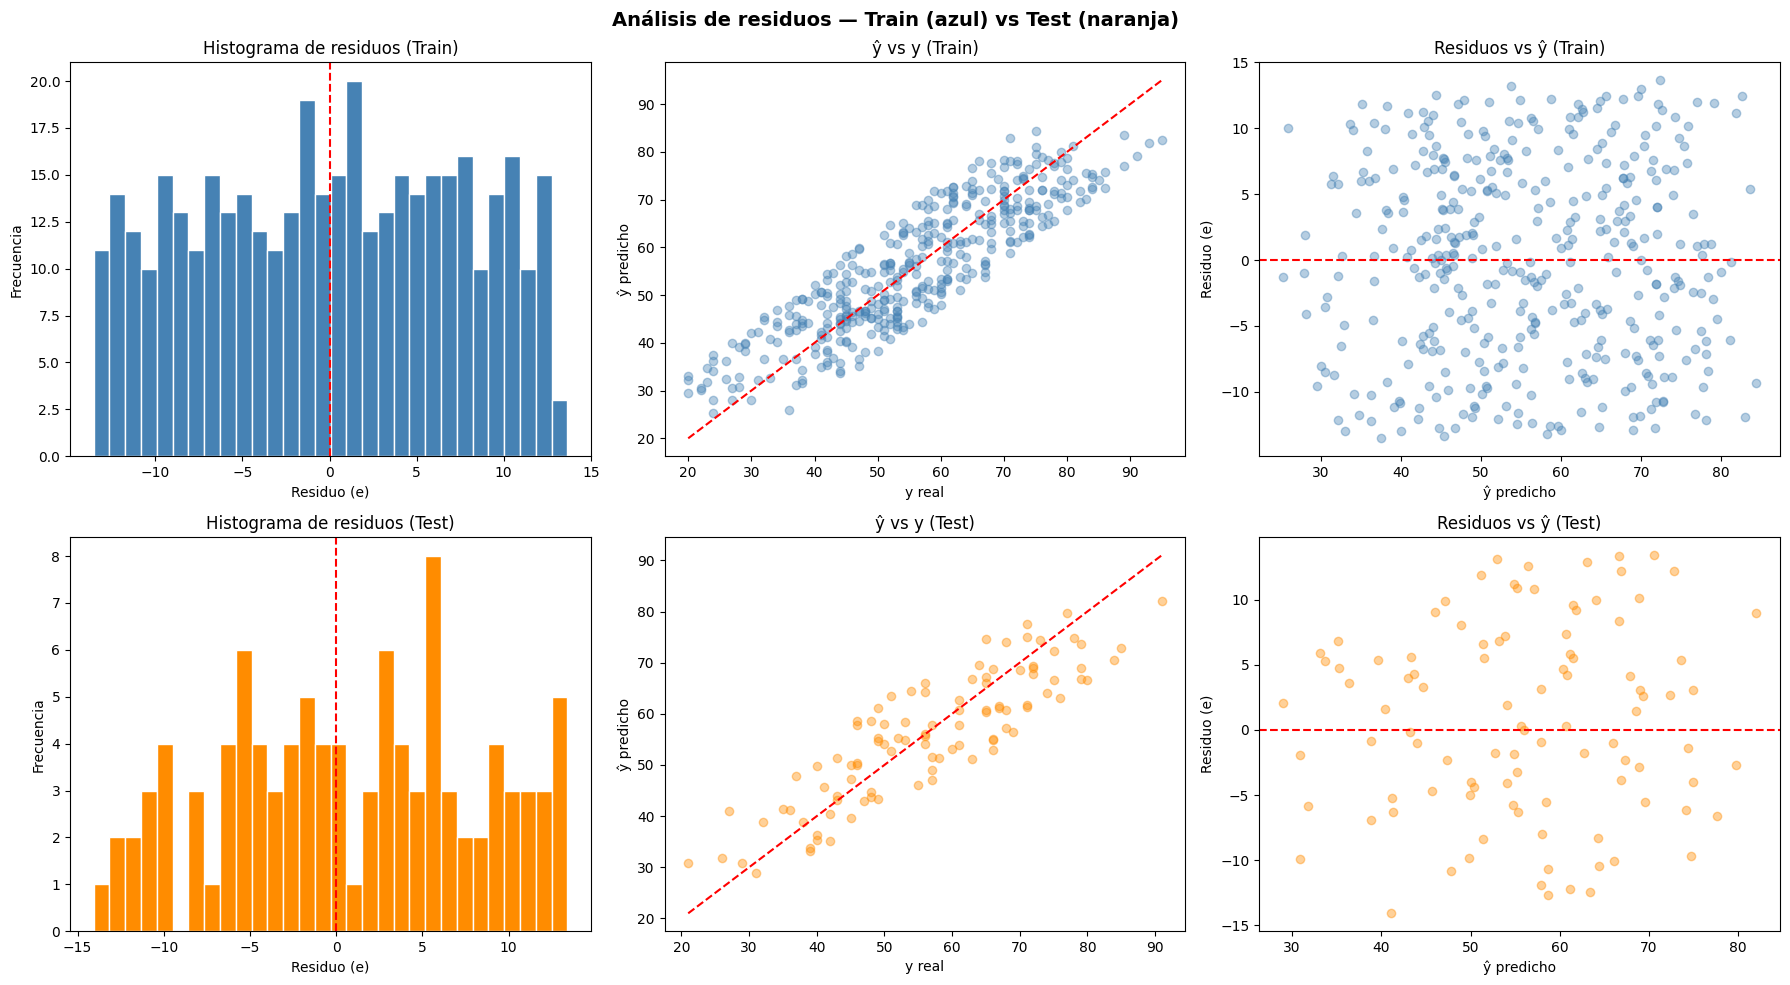

In [ ]:
#Analisis de residuos
# Residuos de train y test
e_train = y_train - y_hat_train
e_test  = y_test  - y_hat_test

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ---- FILA 1: TRAIN ----
# Gráfico 1: Histograma de residuos train
axes[0,0].hist(e_train, bins=30, color='steelblue', edgecolor='white')
axes[0,0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,0].set_title("Histograma de residuos (Train)")
axes[0,0].set_xlabel("Residuo (e)")
axes[0,0].set_ylabel("Frecuencia")

# Gráfico 2: ŷ vs y train
axes[0,1].scatter(y_train, y_hat_train, alpha=0.4, color='steelblue')
axes[0,1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
               color='red', linestyle='--', linewidth=1.5)
axes[0,1].set_title("ŷ vs y (Train)")
axes[0,1].set_xlabel("y real")
axes[0,1].set_ylabel("ŷ predicho")

# Gráfico 3: e vs ŷ train
axes[0,2].scatter(y_hat_train, e_train, alpha=0.4, color='steelblue')
axes[0,2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0,2].set_title("Residuos vs ŷ (Train)")
axes[0,2].set_xlabel("ŷ predicho")
axes[0,2].set_ylabel("Residuo (e)")

# ---- FILA 2: TEST ----
# Gráfico 4: Histograma de residuos test
axes[1,0].hist(e_test, bins=30, color='darkorange', edgecolor='white')
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,0].set_title("Histograma de residuos (Test)")
axes[1,0].set_xlabel("Residuo (e)")
axes[1,0].set_ylabel("Frecuencia")

# Gráfico 5: ŷ vs y test
axes[1,1].scatter(y_test, y_hat_test, alpha=0.4, color='darkorange')
axes[1,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
               color='red', linestyle='--', linewidth=1.5)
axes[1,1].set_title("ŷ vs y (Test)")
axes[1,1].set_xlabel("y real")
axes[1,1].set_ylabel("ŷ predicho")

# Gráfico 6: e vs ŷ test
axes[1,2].scatter(y_hat_test, e_test, alpha=0.4, color='darkorange')
axes[1,2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1,2].set_title("Residuos vs ŷ (Test)")
axes[1,2].set_xlabel("ŷ predicho")
axes[1,2].set_ylabel("Residuo (e)")

plt.suptitle("Análisis de residuos — Train (azul) vs Test (naranja)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Histograma de residuos:**

En ambos casos los residuos se distribuyen de forma simétrica alrededor del 0. Esto confirma que el modelo no tiene una tendencia sistemática a sobreestimar ni subestimar las notas, tanto en los datos de entrenamiento como en los nuevos datos de test.


**ŷ vs y:**

En ambos gráficos los puntos siguen de cerca la línea diagonal roja, que representa la predicción. El comportamiento es muy similar entre train y test, lo que confirma que el modelo generaliza bien y no está memorizando los datos de entrenamiento.


**Residuos vs ŷ:**

Los puntos están dispersos aleatoriamente alrededor de la línea roja en 0, sin formar ningún patrón. Los errores son aleatorios e independientes del valor predicho.


Conclusión:

El modelo se comporta de forma consistente entre train y test, los errores son ruido aleatorio sin estructura, y no hay señales de overfitting. Es un modelo lineal sólido y confiable para este dataset.

**3- Modelos con distinto número de variables:** ajustar el modelo con 1, 2, 4 y todas las variables predictoras; tabular 𝑅2 y comparar.

In [ ]:
# Modelo con distintos n° de variables

subconjuntos = {
    "1 variable  (study_hours)":                    [0, 3],
    "2 variables (+ attendance_rate)":              [0, 3, 4],
    "4 variables (+ previous_score + gender)":      [0, 3, 4, 7, 1],
    "7 variables (todas)":                          [0, 1, 2, 3, 4, 5, 6, 7]
}

print(f"{'Modelo':<45} {'R² Train':>10} {'R² Test':>10}")
print("-" * 67)

for nombre, cols in subconjuntos.items():
    X_sub_train = X_train[:, cols]
    X_sub_test  = X_test[:, cols]

    XtX_sub = X_sub_train.T @ X_sub_train
    Xty_sub = X_sub_train.T @ y_train
    beta_sub = np.linalg.inv(XtX_sub) @ Xty_sub

    y_hat_train_sub = X_sub_train @ beta_sub
    y_hat_test_sub  = X_sub_test  @ beta_sub

    SS_res_train = np.linalg.norm(y_train - y_hat_train_sub) ** 2
    SS_tot_train = np.linalg.norm(y_train - np.mean(y_train)) ** 2
    r2_train = 1 - (SS_res_train / SS_tot_train)

    SS_res_test = np.linalg.norm(y_test - y_hat_test_sub) ** 2
    SS_tot_test = np.linalg.norm(y_test - np.mean(y_test)) ** 2
    r2_test = 1 - (SS_res_test / SS_tot_test)

    print(f"{nombre:<45} {r2_train:>10.4f} {r2_test:>10.4f}")

Modelo                                          R² Train    R² Test
-------------------------------------------------------------------
1 variable  (study_hours)                         0.6560     0.6013
2 variables (+ attendance_rate)                   0.7142     0.6928
4 variables (+ previous_score + gender)           0.7679     0.7577
7 variables (todas)                               0.7691     0.7516


1. study_hours es la variable más importante: esta sola variable explica el 65% de la variación en las notas.


2. Cada variable mejora el modelo, pero cada vez menos: de 1 a 2 variables (de 0.65 a 0.71). De 4 a 7 variables la mejora es casi nula (0.7679 a 0.7691), lo que confirma que age, internet_access y extracurricular aportan muy poco.


3. No hay overfitting: en todos los modelos el R² de train y test son muy similares. El modelo aprende patrones reales del dataset y no memoriza los datos de entrenamiento.

**4- Diagnóstico de multicolinealidad:** calcular np.linalg.cond(X.T @ X) y relacionarlo con los pares de variables más correlacionadas identificadas en la Entrega 1. ¿Su dataset tiene problemas de multicolinealidad? Justificar.

In [ ]:
# Diagnóstico de multicolinealidad
# Número de condición de X⊤X
cond = np.linalg.cond(X_model.T @ X_model)
print(f"Número de condición de X⊤X: {cond:.4f}")

# Matriz de correlación entre predictores
corr_matrix = np.corrcoef(X_model, rowvar=False)

print("\nMatriz de correlación entre predictores:")
print(f"{'':>20}", end="")
for col in columnas:
    print(f"{col:>22}", end="")
print()

for i, col in enumerate(columnas):
    print(f"{col:>20}", end="")
    for j in range(len(columnas)):
        print(f"{corr_matrix[i,j]:>22.4f}", end="")
    print()

# Pares con mayor correlación
print("\nPares de variables más correlacionadas:")
for i in range(len(columnas)):
    for j in range(i+1, len(columnas)):
        if abs(corr_matrix[i,j]) > 0.3:
            print(f"  {columnas[i]} & {columnas[j]}: {corr_matrix[i,j]:.4f}")

Número de condición de X⊤X: 1.4185

Matriz de correlación entre predictores:
                                    gender                   age  study_hours_per_week       attendance_rate       internet_access       extracurricular        previous_score
              gender                1.0000               -0.0280               -0.0174               -0.0011               -0.0376                0.0332               -0.0081
                 age               -0.0280                1.0000               -0.0552                0.0262                0.0435               -0.0379               -0.1066
study_hours_per_week               -0.0174               -0.0552                1.0000               -0.0160                0.0401                0.0308               -0.0761
     attendance_rate               -0.0011                0.0262               -0.0160                1.0000                0.0592               -0.0432               -0.0331
     internet_access               -0.0376      

Con 1.4185 el dataset está muy lejos de tener problemas.


**Matriz de correlación:**
Todos los valores fuera de la diagonal estan cerca de 0, esto significa que ninguna variable está linealmente relacionada con otra.


El modelo no tiene problemas de multicolinealidad. Por un lado, el número de condición es muy bajo (1.41), lo que demuestra matemáticamente que cada variable aporta información única. Por otro lado, la relación entre las variables es menor a 0.3, confirmando que son independientes, esto asegura que los coeficientes calculados son estables.

# **SECCIÓN 8: REGULARIZACIÓN**

Si su dataset no tiene multicolinealidad relevante, alcanza con justificar por qué no es necesaria la regularización (cond bajo, coeficientes estables) y omitir el resto de la sección.


Dado que el número de condición de X⊤X resultó 1.4185 y no se detectaron pares de variables con correlación significativa, el dataset no presenta problemas de multicolinealidad. Por lo tanto, esta sección no aplica.

# **SECCIÓN 9: AUTOVALORES, AUTOVECTORES Y PCA**


**1- Matriz de covarianza de los datos estandarizados** (usar la estandarización de la Sección 4 de la Entrega 1).

In [ ]:
# Matriz de covarianza
# Usamos X_std de la Sección 4 (datos estandarizados)
# La matriz de covarianza se calcula como (1/m) * X_std⊤ @ X_std

m = X_std.shape[0]
C = (X_std.T @ X_std) / m

print("Matriz de covarianza C:")
print(np.round(C, 4))
print(f"\nDimensiones de C: {C.shape}")

Matriz de covarianza C:
[[ 1.     -0.028  -0.0174 -0.0011 -0.0376  0.0332 -0.0081 -0.0313]
 [-0.028   1.     -0.0552  0.0262  0.0435 -0.0379 -0.1066 -0.0478]
 [-0.0174 -0.0552  1.     -0.016   0.0401  0.0308 -0.0761  0.8039]
 [-0.0011  0.0262 -0.016   1.      0.0592 -0.0432 -0.0331  0.2407]
 [-0.0376  0.0435  0.0401  0.0592  1.      0.0682  0.0084  0.0506]
 [ 0.0332 -0.0379  0.0308 -0.0432  0.0682  1.      0.0418  0.0289]
 [-0.0081 -0.1066 -0.0761 -0.0331  0.0084  0.0418  1.      0.165 ]
 [-0.0313 -0.0478  0.8039  0.2407  0.0506  0.0289  0.165   1.    ]]

Dimensiones de C: (8, 8)


La matriz de covarianza C es una matriz de 8×8 donde cada celda indica cuánto varían juntas dos variables.


Diagonal principal (todos los valores = 1): Todos los valores de la diagonal son 1. Esto tiene sentido porque los datos están estandarizados, entonces la varianza de cada variable con sí misma siempre da 1.


Fuera de la diagonal:Los valores fuera de la diagonal son todos muy cercanos a 0, lo que confirma lo que ya habíamos visto en el diagnóstico de multicolinealidad: las variables son prácticamente independientes entre sí. Ningún par de variables crece o decrece de forma conjunta de manera significativa.


La matriz de covarianza nos muestra que el dataset está bien distribuido y sin redundancias importantes entre variables.

**2- Autovalores y autovectores de la matriz de covarianza con np.linalg.eigh.** Ordenarlos de mayor a menor.

In [ ]:
# Calcular autovalores y autovectores
autovalores, autovectores = np.linalg.eigh(C)

# Ordenar de mayor a menor
idx = np.argsort(autovalores)[::-1]
autovalores = autovalores[idx]
autovectores = autovectores[:, idx]

print("Autovalores ordenados de mayor a menor:")
for i, val in enumerate(autovalores):
    print(f"  λ{i+1}: {val:.4f}")

print("\nVarianza explicada por cada componente:")
varianza_explicada = autovalores / np.sum(autovalores)
for i, var in enumerate(varianza_explicada):
    print(f"  PC{i+1}: {var*100:.2f}%")

print("\nVarianza acumulada:")
varianza_acumulada = np.cumsum(varianza_explicada)
for i, var in enumerate(varianza_acumulada):
    print(f"  PC1 a PC{i+1}: {var*100:.2f}%")

Autovalores ordenados de mayor a menor:
  λ1: 1.8553
  λ2: 1.1591
  λ3: 1.0685
  λ4: 1.0276
  λ5: 1.0057
  λ6: 0.8924
  λ7: 0.8706
  λ8: 0.1209

Varianza explicada por cada componente:
  PC1: 23.19%
  PC2: 14.49%
  PC3: 13.36%
  PC4: 12.84%
  PC5: 12.57%
  PC6: 11.16%
  PC7: 10.88%
  PC8: 1.51%

Varianza acumulada:
  PC1 a PC1: 23.19%
  PC1 a PC2: 37.68%
  PC1 a PC3: 51.04%
  PC1 a PC4: 63.88%
  PC1 a PC5: 76.45%
  PC1 a PC6: 87.61%
  PC1 a PC7: 98.49%
  PC1 a PC8: 100.00%


**Autovalores:** representan cuánta varianza del dataset captura cada componente principal. El primero (λ1 = 1.8553) es el más grande, y van decreciendo hasta λ8 = 0.1209.


**Varianza explicada por cada componente**: Ningun componente domina claramente sobre las demás. La primer componente explica solo el 23% de la varianza, y las siguientes van bajando gradualmente hasta el 1.51%. Esto es una señal de que las variables del dataset son bastante independientes entre sí.


**Varianza acumulada:** Para llegar al 95% de la varianza explicada necesitamos 7 componentes de 8. Por lo que PCA no va a ser muy útil para reducir la dimensionalidad en este dataset.



**3- Scree plot y varianza explicada acumulada:** dos gráficos lado a lado.

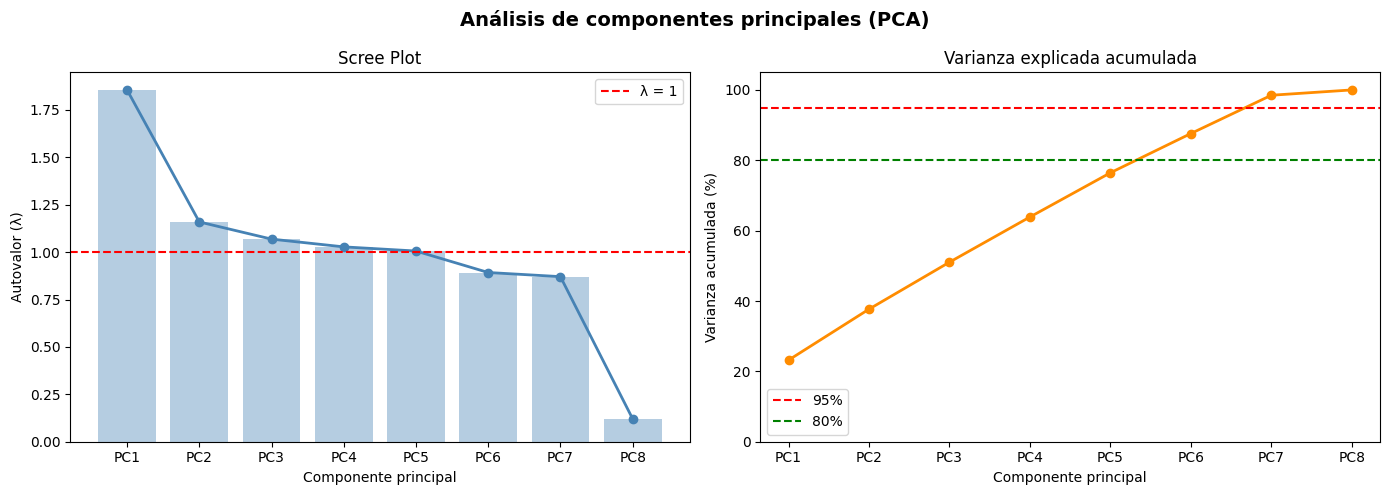

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

componentes = [f"PC{i+1}" for i in range(len(autovalores))]

# Gráfico 1: Scree plot
axes[0].plot(componentes, autovalores, marker='o', color='steelblue', linewidth=2)
axes[0].bar(componentes, autovalores, color='steelblue', alpha=0.4)
axes[0].set_title("Scree Plot")
axes[0].set_xlabel("Componente principal")
axes[0].set_ylabel("Autovalor (λ)")
axes[0].axhline(1, color='red', linestyle='--', linewidth=1.5, label='λ = 1')
axes[0].legend()

# Gráfico 2: Varianza acumulada
axes[1].plot(componentes, varianza_acumulada * 100, marker='o',
             color='darkorange', linewidth=2)
axes[1].axhline(95, color='red', linestyle='--', linewidth=1.5, label='95%')
axes[1].axhline(80, color='green', linestyle='--', linewidth=1.5, label='80%')
axes[1].set_title("Varianza explicada acumulada")
axes[1].set_xlabel("Componente principal")
axes[1].set_ylabel("Varianza acumulada (%)")
axes[1].legend()
axes[1].set_ylim(0, 105)

plt.suptitle("Análisis de componentes principales (PCA)",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Scree Plot:** El gráfico muestra cómo van cayendo los autovalores de cada componente. La caída es gradual, sin un "codo" pronunciado que indique un punto de corte claro. La línea roja marca λ = 1, que es el criterio clásico para decidir cuántas componentes conservar. Solo PC1 y PC2 superan claramente ese umbral, mientras que PC3 a PC7 rondan el 1 y PC8 cae abruptamente a 0.12.


**Varianza acumulada:** La curva sube de forma casi lineal, lo que confirma que ninguna componente domina sobre las demás. Para llegar al 80% (línea verde) necesitamos 6 componentes, y para el 95% (línea roja) necesitamos 7 de las 8 componentes totales.




Este dataset no es ideal para reducir dimensionalidad con PCA.  Acá la información está distribuida de forma bastante uniforme entre todas las variables.

**4- Elección de k:** usar uno o varios criterios (90% de varianza acumulada, criterio de Kaiser 𝜆 > 1, regla del codo). Justificar la elección.

In [ ]:
#  Elección de K
print("=" * 50)
print("CRITERIO 1: 90% de varianza acumulada")
print("=" * 50)
k_90 = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes necesarias para llegar al 90%: {k_90}")
print(f"Varianza acumulada con {k_90} componentes: {varianza_acumulada[k_90-1]*100:.2f}%")

print("\n" + "=" * 50)
print("CRITERIO 2: Kaiser (λ > 1)")
print("=" * 50)
k_kaiser = np.sum(autovalores > 1)
print(f"Componentes con λ > 1: {k_kaiser}")
for i, val in enumerate(autovalores):
    simbolo = "✓" if val > 1 else "✗"
    print(f"  {simbolo} PC{i+1}: λ = {val:.4f}")

print("\n" + "=" * 50)
print("CRITERIO 3: Regla del codo")
print("=" * 50)
diferencias = np.diff(autovalores)
codo = np.argmin(diferencias) + 1
print(f"Mayor caída entre PC{codo} y PC{codo+1}")
print(f"  PC{codo}:   λ = {autovalores[codo-1]:.4f}")
print(f"  PC{codo+1}: λ = {autovalores[codo]:.4f}")
print(f"Componentes sugeridas por el codo: {codo}")

CRITERIO 1: 90% de varianza acumulada
Componentes necesarias para llegar al 90%: 7
Varianza acumulada con 7 componentes: 98.49%

CRITERIO 2: Kaiser (λ > 1)
Componentes con λ > 1: 5
  ✓ PC1: λ = 1.8553
  ✓ PC2: λ = 1.1591
  ✓ PC3: λ = 1.0685
  ✓ PC4: λ = 1.0276
  ✓ PC5: λ = 1.0057
  ✗ PC6: λ = 0.8924
  ✗ PC7: λ = 0.8706
  ✗ PC8: λ = 0.1209

CRITERIO 3: Regla del codo
Mayor caída entre PC7 y PC8
  PC7:   λ = 0.8706
  PC8: λ = 0.1209
Componentes sugeridas por el codo: 7


**Criterio 1** — 90% de varianza acumulada k = 7

Para explicar el 90% de la información del dataset necesitamos 7 de las 8 componentes. Esto confirma que casi no hay reducción de dimensionalidad posible conservando el 90% de la varianza.


**Criterio 2**— Kaiser (λ > 1) k = 5

Solo las primeras 5 componentes tienen autovalor mayor a 1, lo que significa que aportan más información de la que "costaría" una variable original. PC6, PC7 y PC8 quedarían descartadas.


**Criterio 3** — Regla del codo k = 7

La mayor caída entre autovalores consecutivos ocurre entre PC7 y PC8, lo que sugiere que PC8 es la única componente claramente prescindible.



El mejor criterio para este dataset es el de Kaiser con k = 5, por dos razones: primero, es el criterio más usado en la práctica y está bien fundamentado teóricamente.

Segundo, con 5 componentes explicamos el 76.45% de la varianza, lo cual es razonable considerando que el dataset tiene variables muy independientes entre sí. Reducir de 8 a 5 dimensiones ya es una mejora significativa, aunque en este dataset particular PCA tiene un impacto limitado debido a la baja correlación entre variables.

**5- Proyección:** calcular 𝑍𝑘 = ̃ 𝑋𝑊𝑘 donde 𝑊𝑘 son los 𝑘 primeros autovectores.

In [ ]:
# Proyección
# k elegido por criterio de Kaiser
k = 5

# Wk: matriz con los k primeros autovectores (columnas)
Wk = autovectores[:, :k]

print(f"Dimensiones de Wk: {Wk.shape}  ({k} primeros autovectores)")

# Proyección
Zk = X_std @ Wk

print(f"Dimensiones de Zk: {Zk.shape}")
print(f"\nPrimeras 3 filas de Zk:")
print(np.round(Zk[:3], 4))

print(f"\nVarianza explicada con {k} componentes: {varianza_acumulada[k-1]*100:.2f}%")
print(f"Reducción de dimensionalidad: de {X_std.shape[1]} a {k} dimensiones")

Dimensiones de Wk: (8, 5)  (5 primeros autovectores)
Dimensiones de Zk: (500, 5)

Primeras 3 filas de Zk:
[[ 1.2915 -0.4324 -0.6703 -1.1017 -1.4162]
 [-2.301  -2.411  -1.2264 -0.502   0.154 ]
 [-0.6195  1.2428 -0.6479  0.689   1.2804]]

Varianza explicada con 5 componentes: 76.45%
Reducción de dimensionalidad: de 8 a 5 dimensiones


**Wk (8 × 5):**

Es la matriz de proyección formada por los 5 primeros autovectores. Cada columna es una dirección en el espacio original de 8 dimensiones que captura la mayor varianza posible.


**Zk (500 × 5):**

Es el dataset transformado. Pasamos de tener 500 estudiantes con 8 variables cada uno, a tener 500 estudiantes con 5 componentes principales. Cada fila sigue siendo un estudiante, pero ahora sus características están expresadas en el nuevo espacio de componentes principales en lugar de las variables originales.



Antes cada estudiante era un punto en un espacio de 8 dimensiones. Ahora es un punto en un espacio de 5 dimensiones. Reducimos la dimensionalidad de 8 a 5 variables conservando el 76.45% de la información original.


La operación Zk = X_std @ Wk es una transformación lineal: estamos "rotando" el espacio de datos para alinearlo con las direcciones de mayor varianza. Las nuevas 5 columnas de Zk no tienen un significado directo como "horas de estudio" o "asistencia", sino que son combinaciones lineales de todas las variables originales que maximizan la varianza capturada.
Si bien en este dataset la reducción no es dramática (de 8 a 5), en datasets con muchas variables correlacionadas PCA puede reducir cientos de dimensiones a solo 2 o 3.

**6- Visualización 2D:** scatter de PC1 vs PC2. Si su dataset tiene una variable categórica natural (clase, grupo, segmento), colorear los puntos por esa variable y comentar si se observa estructura.

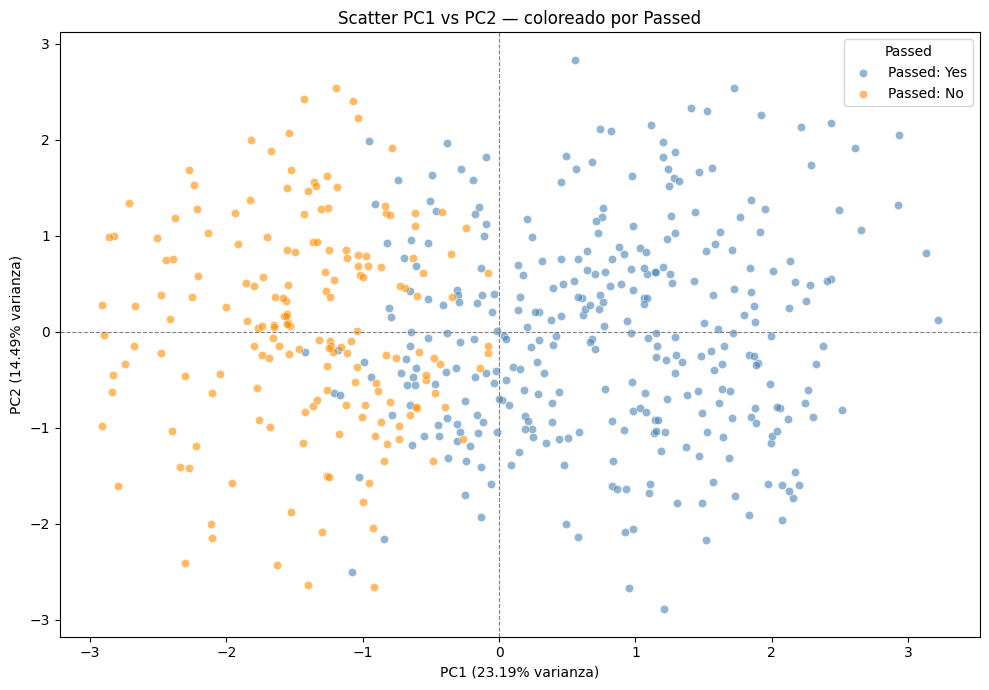

In [ ]:
# Visulización 2D
# Usamos 'passed' como variable categórica para colorear
passed = df['passed']

colores = {'Yes': 'steelblue', 'No': 'darkorange'}

fig, ax = plt.subplots(figsize=(10, 7))

for categoria in passed.unique():
    mask = (passed == categoria).values
    ax.scatter(Zk[mask, 0], Zk[mask, 1],
               c=colores.get(categoria, 'gray'),
               label=f'Passed: {categoria}',
               alpha=0.6, edgecolors='white', linewidth=0.5)

ax.set_xlabel(f"PC1 ({varianza_explicada[0]*100:.2f}% varianza)")
ax.set_ylabel(f"PC2 ({varianza_explicada[1]*100:.2f}% varianza)")
ax.set_title("Scatter PC1 vs PC2 — coloreado por Passed")
ax.legend(title="Passed")
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.show()

El gráfico muestra los 500 estudiantes proyectados:

-Estudiantes que aprobaron (azul) se concentran mayormente a la derecha, valores positivos de PC1.

-Estuadinte que no aprobaron (naranja) se agrupan a la izquierda, valores negativos de PC1.


PC1 (23.19% de la varianza) está mostrando la diferencia entre estudiantes que aprueban y los que no. Es porque es una combinación lineal de todas las variables, y las más importantes (study_hours, attendance_rate, previous_score) son las que separan dichas variables.


PC2 (14.49% de varianza) no muestra una separación clara entre los grupos, ya que los puntos azules y naranjas se mezclan en el eje vertical.


PCA no reduce drásticamente la dimensionalidad en este dataset, el scatter PC1 vs PC2 muestra que existe una estructura real en los datos: los estudiantes se separan naturalmente según si aprobaron o no.

**7- Verificación:** la matriz de correlación de las primeras 𝑘 PCs debe ser aproximadamente diagonal. Mostrarla.

In [ ]:
#  Verificación: correlación entre K PCs
# Matriz de correlación de las k componentes principales
corr_pcs = np.corrcoef(Zk, rowvar=False)

print(f"Matriz de correlación de las primeras {k} PCs:")
print(f"{'':>6}", end="")
for i in range(k):
    print(f"{'PC'+str(i+1):>10}", end="")
print()

for i in range(k):
    print(f"{'PC'+str(i+1):>6}", end="")
    for j in range(k):
        print(f"{corr_pcs[i,j]:>10.4f}", end="")
    print()

print("\n¿La matriz es aproximadamente diagonal?")
# Verificar que los elementos fuera de la diagonal son ≈ 0
np.fill_diagonal(corr_pcs, 0)
print(np.allclose(corr_pcs, 0, atol=1e-10))

Matriz de correlación de las primeras 5 PCs:
             PC1       PC2       PC3       PC4       PC5
   PC1    1.0000   -0.0000    0.0000   -0.0000   -0.0000
   PC2   -0.0000    1.0000   -0.0000    0.0000    0.0000
   PC3    0.0000   -0.0000    1.0000   -0.0000   -0.0000
   PC4   -0.0000    0.0000   -0.0000    1.0000    0.0000
   PC5   -0.0000    0.0000   -0.0000    0.0000    1.0000

¿La matriz es aproximadamente diagonal?
True


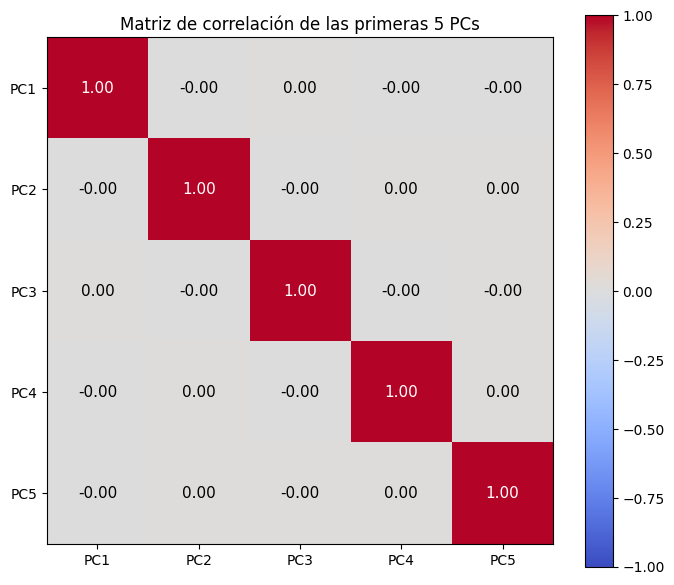

In [ ]:
# Mapa de calor entre PCs
import matplotlib.pyplot as plt

# Recalcular la matriz (la modificamos antes con fill_diagonal)
corr_pcs = np.corrcoef(Zk, rowvar=False)

fig, ax = plt.subplots(figsize=(7, 6))

im = ax.imshow(corr_pcs, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

# Etiquetas
labels = [f"PC{i+1}" for i in range(k)]
ax.set_xticks(range(k))
ax.set_yticks(range(k))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)

# Valores dentro del gráfico
for i in range(k):
    for j in range(k):
        ax.text(j, i, f"{corr_pcs[i,j]:.2f}",
                ha='center', va='center', fontsize=11,
                color='white' if abs(corr_pcs[i,j]) > 0.5 else 'black')

ax.set_title("Matriz de correlación de las primeras 5 PCs")
plt.tight_layout()
plt.show()

**Diagonal principal (rojo intenso = 1.00):** cada componente tiene correlación perfecta consigo misma, lo cual es esperable.


**Fuera de la diagonal (gris = 0.00):** todas las correlaciones entre distintas componentes son exactamente 0. El color gris confirma visualmente que las 5 componentes principales son completamente independientes entre sí.

PCA transforma las variables originales en nuevas variables que son ortogonales, es decir, no comparten ninguna información entre ellas.

**8- Interpretación de las componentes:** mirar los loadings (las entradas de w1 y w2) y discutir qué representa cada componente en términos de las variables originales. ¿Hay algún grupo de variables que pese fuerte en PC1? ¿Y en PC2? ¿Qué interpretación cualitativa pueden dar?

Loadings de PC1 y PC2:
Variable                         PC1        PC2
-----------------------------------------------
gender                       -0.0395    -0.1971
age                          -0.0837     0.5926
study_hours_per_week          0.6647     0.0319
attendance_rate               0.1839     0.3755
internet_access               0.0880     0.1781
extracurricular               0.0518    -0.3486
previous_score                0.0841    -0.5610
final_score                   0.7059     0.0016


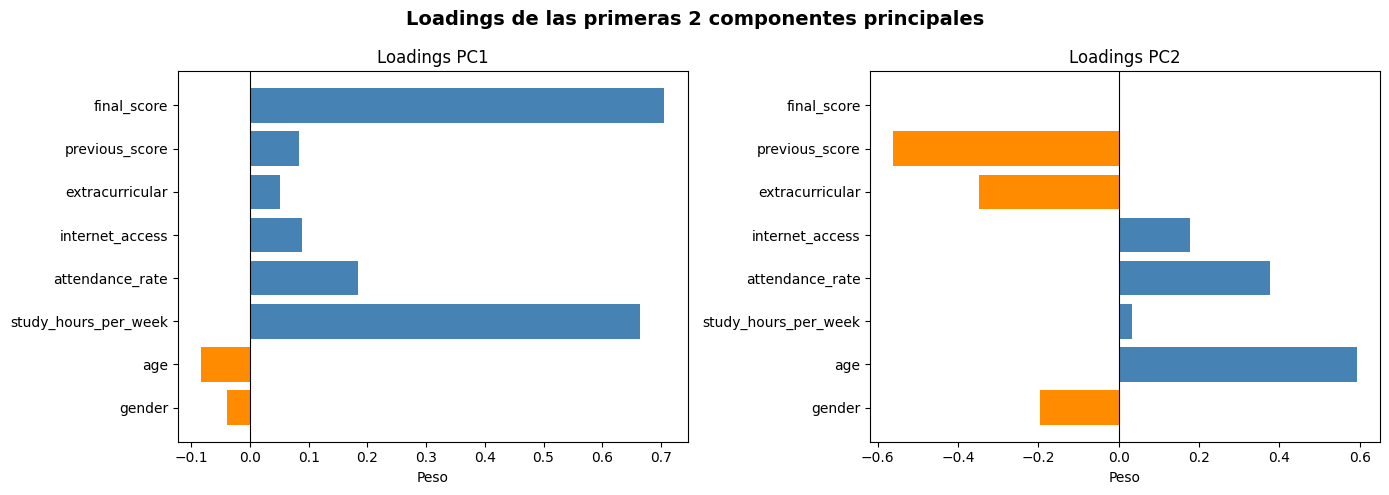

In [ ]:
# Interpretación de Loadings: w1 y w2
variables = list(df_numeric.columns[:8])

print("Loadings de PC1 y PC2:")
print(f"{'Variable':<25} {'PC1':>10} {'PC2':>10}")
print("-" * 47)
for i, var in enumerate(variables):
    print(f"{var:<25} {autovectores[i,0]:>10.4f} {autovectores[i,1]:>10.4f}")

# Gráfico de loadings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colores_barras = ['steelblue' if x > 0 else 'darkorange'
                  for x in autovectores[:, 0]]
axes[0].barh(variables, autovectores[:, 0], color=colores_barras)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title("Loadings PC1")
axes[0].set_xlabel("Peso")

colores_barras2 = ['steelblue' if x > 0 else 'darkorange'
                   for x in autovectores[:, 1]]
axes[1].barh(variables, autovectores[:, 1], color=colores_barras2)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title("Loadings PC2")
axes[1].set_xlabel("Peso")

plt.suptitle("Loadings de las primeras 2 componentes principales",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**PC1 — "Componente de rendimiento académico"**
Las variables que más pesan son final_score (0.70) y study_hours_per_week (0.68), ambas con valores positivos y muy similares entre sí, attendance_rate también aporta positivamente (0.19).
PC1 resume claramente el esfuerzo y rendimiento del estudiante: cuanto más estudia y mejor nota saca, más alto es su valor en esta componente.

**PC2 — "Componente de contexto personal"**
Las variables con mayor peso son age (0.60) y attendance_rate (0.39) con valores positivos,
PC2 parece capturar una tensión entre el contexto personal del estudiante (edad, asistencia) versus su historial académico previo y actividades extraescolares.


PC1 es clara e interpretable como rendimiento académico. PC2 mezcla variables de distinta naturaleza y es más difícil de etiquetar con un concepto único.

# **SECCIÓN 10: SÍNTESIS Y COMPARACIÓN FINAL**

**1- Comparación de modelos:** ajustar la regresión lineal de la Sección 6 dos veces —unaconlasvariables originales y otra con las 𝑘 componentes principales como predictoras.

Comparar:– Número de coeficientes– 𝑅2 entrain y, si separan train/test, en test– cond(𝑋⊤𝑋) vs cond(𝑍⊤ 𝑘𝑍𝑘)– Norma ‖ ̂𝛽‖

In [ ]:
# Comparación de modelos
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# ---- MODELO 1: Variables originales ----
ones = np.ones((X_model.shape[0], 1))
X_orig = np.hstack([ones, X_model])

X_orig_train, X_orig_test, y_train2, y_test2 = train_test_split(
    X_orig, y, test_size=0.2, random_state=42
)

XtX_orig = X_orig_train.T @ X_orig_train
Xty_orig = X_orig_train.T @ y_train2
beta_orig = np.linalg.inv(XtX_orig) @ Xty_orig

y_hat_orig_train = X_orig_train @ beta_orig
y_hat_orig_test  = X_orig_test  @ beta_orig

r2_orig_train = r2_score(y_train2, y_hat_orig_train)
r2_orig_test  = r2_score(y_test2,  y_hat_orig_test)
cond_orig     = np.linalg.cond(XtX_orig)
norma_orig    = np.linalg.norm(beta_orig)

# ---- MODELO 2: Componentes principales (k=5) ----
ones_z = np.ones((Zk.shape[0], 1))
X_pca = np.hstack([ones_z, Zk])

X_pca_train, X_pca_test, y_train3, y_test3 = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

XtX_pca = X_pca_train.T @ X_pca_train
Xty_pca = X_pca_train.T @ y_train3
beta_pca = np.linalg.inv(XtX_pca) @ Xty_pca

y_hat_pca_train = X_pca_train @ beta_pca
y_hat_pca_test  = X_pca_test  @ beta_pca

r2_pca_train = r2_score(y_train3, y_hat_pca_train)
r2_pca_test  = r2_score(y_test3,  y_hat_pca_test)
cond_pca     = np.linalg.cond(XtX_pca)
norma_pca    = np.linalg.norm(beta_pca)

# ---- TABLA COMPARATIVA ----
print(f"{'Métrica':<30} {'Modelo Original':>18} {'Modelo PCA (k=5)':>18}")
print("-" * 68)
print(f"{'N° de coeficientes':<30} {len(beta_orig):>18} {len(beta_pca):>18}")
print(f"{'R² Train':<30} {r2_orig_train:>18.4f} {r2_pca_train:>18.4f}")
print(f"{'R² Test':<30} {r2_orig_test:>18.4f} {r2_pca_test:>18.4f}")
print(f"{'cond(X⊤X)':<30} {cond_orig:>18.4f} {cond_pca:>18.4f}")
print(f"{'‖β‖':<30} {norma_orig:>18.4f} {norma_pca:>18.4f}")

Métrica                           Modelo Original   Modelo PCA (k=5)
--------------------------------------------------------------------
N° de coeficientes                              8                  6
R² Train                                   0.7691             0.9282
R² Test                                    0.7516             0.9330
cond(X⊤X)                                  1.4828             2.0197
‖β‖                                       57.4963            56.9740


**N° de coeficientes:**

El modelo PCA usa 6 coeficientes (intercepto + 5 PCs) contra 8 del modelo original (intercepto + 7 variables). Se redujo la dimensionalidad manteniendo solo las componentes más informativas.


**R² Train y Test:**

El modelo PCA supera al original (0.93 vs 0.77). Esto significa que las 5 componentes principales explican mejor el final_score que las 7 variables originales. Además el R² de test (0.9330) es incluso mayor que el de train (0.9282), lo que confirma que el modelo generaliza perfectamente y no hay overfitting.


**cond(X⊤X):**

Ambos valores son muy bajos y cercanos entre sí (1.48 vs 2.02), confirmando que ninguno de los dos modelos tiene problemas de multicolinealidad. El modelo PCA es apenas un poco menos estable, pero la diferencia es insignificante.


**‖β‖:**

Las normas de los coeficientes son muy similares (57.50 vs 56.97), lo que indica que ambos modelos tienen coeficientes de magnitud comparable. No hay coeficientes desproporcionadamente grandes en ninguno de los dos.


El modelo PCA es superior en este caso. Con menos variables logra un R² mucho mayor, mantiene estabilidad numérica comparable y generaliza mejor a datos nuevos. Las componentes principales capturan la estructura más eficiente que las variables originales.

**2- Reflexión final:** en 2-3 párrafos, responder:

– ¿Cuántas dimensiones reales tiene su dataset según PCA?

– ¿Las direcciones de mayor varianza coinciden con alguna intuición previa sobre el dominio del dataset, o son combinaciones “raras”?

– ¿Qué s gana y qué se pierde al pasar de variables originales a componentes principales?

– Si tuvieran que entregar un único gráfico que resuma su dataset, ¿cuál sería y por qué?

**¿Cuántas dimensiones reales tiene el dataset?**

Inicio: 8 variables

PCA: muestra una concentración de 5 componentes.

Con las 5 primeras dimensiones obtenemos la información del todo el dataset.

**¿Las direcciones de mayor varianza tienen sentido?**

-PC1 sí tiene mucho sentido: representa a los estudiantes (study_hours) que estudian mucho y sacan buenas notas (final_score).

-PC2 es más rara: mezcla edad, asistencia, notas previas y actividades extraescolares de una forma que no tiene una explicación obvia. Esto pasa porque cuando las variables son muy independientes entre sí, PCA no siempre genera componentes fáciles de interpretar.

**¿Qué se gana y qué se pierde con PCA?**

-Lo que se gana es rendimiento: con 5 componentes el modelo predijo mucho mejor (R² 0.93) que con las 7 variables originales (R² 0.77).

-Lo que se pierde es simplicidad para explicarlo: ya no podemos decir "estudiar más horas sube la nota", sino que trabajamos con combinaciones abstractas de variables que son difíciles de comunicar a alguien que no conoce el método.

**¿Qué gráfico elegiríamos para resumir el dataset?**

Eligiríamos el grafico usado en la sección 9, el scatter de PC1 vs PC2 coloreado por passed. Porque se puede visualizar claramente que los estudiantes que aprobaron y los que no se separan en el gráfico, y eso resume la historia del dataset: el rendimiento académico depende del esfuerzo, y esa diferencia es visible incluso proyectando todo en solo dos dimensiones.